# Collect MI Results from Disk & Plot MI Scaling

In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from itertools import product
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

DATA_ROOT = Path('/home/igor/noise_scaling/data')

ALGOS = ['Geneformer', 'PCA', 'RandomProjection', 'SCVI', 'State']

EXPECTED = {
    'PBMC': {
        'sizes': [100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000],
        'qualities': [0.0012346, 0.0025982, 0.0054682, 0.0115083, 0.02422, 0.050973, 0.1072766, 0.225772, 0.4751547, 1.0],
        'signals': ['protein_counts'],
        'seeds': [42],
    },
    'larry': {
        'sizes': [100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000],
        'qualities': [0.003876, 0.0071835, 0.0133136, 0.0246748, 0.0457311, 0.0847557, 0.1570821, 0.2911284, 0.5395631, 1.0],
        'signals': ['clone'],
        'seeds': [42],
    },
    'merfish': {
        'sizes': [100, 203, 414, 843, 1716, 3494, 7113, 14480, 29475, 60000],
        'qualities': [0.027248, 0.0406617, 0.0606789, 0.0905502, 0.1351267, 0.2016475, 0.3009156, 0.4490518, 0.6701133, 1.0],
        'signals': ['ng_idx'],
        'seeds': [42],
    },
    'shendure': {
        'sizes': [100, 359, 1291, 4641, 16681, 59948, 215443, 774263, 2782559, 10000000],
        'qualities': [0.004, 0.0073875, 0.0136438, 0.0251984, 0.0465384, 0.0859506, 0.1587401, 0.2931733, 0.5414548, 1.0],
        'signals': ['author_day'],
        'seeds': [42],
    },
}

/home/igor/miniconda3/envs/modeling/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def _read_mi(path):
    try:
        with open(path) as f:
            return float(f.read().strip())
    except Exception:
        return np.nan

# Build expected paths for ALL algorithms (including State)
expected_rows = []
for ds, cfg in EXPECTED.items():
    for sz, q, algo, sig, sd in product(cfg['sizes'], cfg['qualities'], ALGOS, cfg['signals'], cfg['seeds']):
        suffix = '_geneformer' if algo == 'Geneformer' else ''
        stem = f'Y_{sig}_{q}{suffix}'
        mi_path = DATA_ROOT / ds / str(sz) / str(q) / 'results' / algo / 'model' / 'MI' / str(sd) / stem / 'lmi_mutual_information.txt'
        expected_rows.append({
            'dataset': ds, 'size': sz, 'quality': q, 'algorithm': algo,
            'signal': sig, 'seed': sd, 'path': str(mi_path),
        })

df_expected = pd.DataFrame(expected_rows)
print(f'Total expected: {len(df_expected)}')

# Check existence in parallel
with ThreadPoolExecutor(max_workers=128) as pool:
    df_expected['exists'] = list(tqdm(pool.map(os.path.exists, df_expected['path']),
                                      total=len(df_expected), desc='Scanning'))

# Read MI values for found files
df_found = df_expected[df_expected['exists']].copy()
print(f'Found: {len(df_found)}, Missing: {len(df_expected) - len(df_found)}')

with ThreadPoolExecutor(max_workers=128) as pool:
    df_found['mi_value'] = list(tqdm(pool.map(_read_mi, df_found['path']),
                                     total=len(df_found), desc='Reading MI'))

# Final dataframe
out_cols = ['dataset', 'size', 'quality', 'algorithm', 'signal', 'seed', 'mi_value']
df_results = df_found[out_cols].sort_values(out_cols[:-1]).reset_index(drop=True)
print(f'Collected {len(df_results)} MI values (NaN: {df_results["mi_value"].isna().sum()})')

Total expected: 2000


Scanning: 100%|██████████| 2000/2000 [00:00<00:00, 499619.30it/s]


Found: 1797, Missing: 203


Reading MI: 100%|██████████| 1797/1797 [00:00<00:00, 482594.72it/s]

Collected 1797 MI values (NaN: 0)


In [3]:
# Completeness table: found / expected / missing per dataset × algorithm
pivot = df_expected.groupby(['dataset', 'algorithm'])['exists'].agg(['sum', 'count'])
pivot.columns = ['found', 'expected']
pivot['missing'] = pivot['expected'] - pivot['found']
pivot = pivot.astype(int)

pivot_wide = pivot.unstack('algorithm', fill_value=0).sort_index()
display(pivot_wide)

found                                    expected       \
algorithm Geneformer  PCA RandomProjection SCVI State Geneformer  PCA   
dataset                                                                 
PBMC             100  100              100  100   100        100  100   
larry            100  100              100  100     1        100  100   
merfish           96  100              100   99   100        100  100   
shendure         100  100              100  100     1        100  100   

                                         missing                            \
algorithm RandomProjection SCVI State Geneformer PCA RandomProjection SCVI   
dataset                                                                      
PBMC                   100  100   100          0   0                0    0   
larry                  100  100   100          0   0                0    0   
merfish                100  100   100          4   0                0    1   
shendure               100  100   100          0   0                0    0   

                 
algorithm State  
dataset          
PBMC          0  
larry        99  
merfish       0  
shendure     99

In [4]:
# Detailed State completeness: rows=size, cols=quality, values=seeds found (0 or 1)
# One table per dataset
df_state_exp = df_expected[df_expected['algorithm'] == 'State'].copy()

for ds in EXPECTED:
    sub = df_state_exp[df_state_exp['dataset'] == ds]
    grid = sub.groupby(['size', 'quality'])['exists'].sum().astype(int).unstack('quality', fill_value=0)
    grid.columns = [f'{q:.4g}' for q in grid.columns]
    grid.index.name = 'size'
    total_found = grid.values.sum()
    total_expected = len(sub)
    print(f'\n{ds}  —  State completeness ({total_found}/{total_expected})')
    display(grid)


PBMC  —  State completeness (100/100)


,0.001235,0.002598,0.005468,0.01151,0.02422,0.05097,0.1073,0.2258,0.4752,1
size,,,,,,,,,,
100,1,1,1,1,1,1,1,1,1,1
215,1,1,1,1,1,1,1,1,1,1
464,1,1,1,1,1,1,1,1,1,1
1000,1,1,1,1,1,1,1,1,1,1
2154,1,1,1,1,1,1,1,1,1,1
4641,1,1,1,1,1,1,1,1,1,1
10000,1,1,1,1,1,1,1,1,1,1
21544,1,1,1,1,1,1,1,1,1,1
46415,1,1,1,1,1,1,1,1,1,1



larry  —  State completeness (1/100)


,0.003876,0.007183,0.01331,0.02467,0.04573,0.08476,0.1571,0.2911,0.5396,1
size,,,,,,,,,,
100,0,0,0,0,0,0,0,0,0,0
215,0,0,0,0,0,0,0,0,0,0
464,0,0,0,0,0,0,0,0,0,0
1000,0,0,0,0,0,0,0,0,0,0
2154,0,0,0,0,0,0,0,0,0,0
4641,0,0,0,0,0,0,0,0,0,0
10000,0,0,0,0,0,0,0,0,0,0
21544,0,0,0,0,0,0,0,0,0,0
46415,0,0,0,0,0,0,0,0,0,1



merfish  —  State completeness (100/100)


,0.02725,0.04066,0.06068,0.09055,0.1351,0.2016,0.3009,0.4491,0.6701,1
size,,,,,,,,,,
100,1,1,1,1,1,1,1,1,1,1
203,1,1,1,1,1,1,1,1,1,1
414,1,1,1,1,1,1,1,1,1,1
843,1,1,1,1,1,1,1,1,1,1
1716,1,1,1,1,1,1,1,1,1,1
3494,1,1,1,1,1,1,1,1,1,1
7113,1,1,1,1,1,1,1,1,1,1
14480,1,1,1,1,1,1,1,1,1,1
29475,1,1,1,1,1,1,1,1,1,1



shendure  —  State completeness (1/100)


,0.004,0.007387,0.01364,0.0252,0.04654,0.08595,0.1587,0.2932,0.5415,1
size,,,,,,,,,,
100,0,0,0,0,0,0,0,0,0,0
359,0,0,0,0,0,0,0,0,0,0
1291,0,0,0,0,0,0,0,0,0,0
4641,0,0,0,0,0,0,0,0,0,0
16681,0,0,0,0,0,0,0,0,0,0
59948,0,0,0,0,0,0,0,0,0,1
215443,0,0,0,0,0,0,0,0,0,0
774263,0,0,0,0,0,0,0,0,0,0
2782559,0,0,0,0,0,0,0,0,0,0


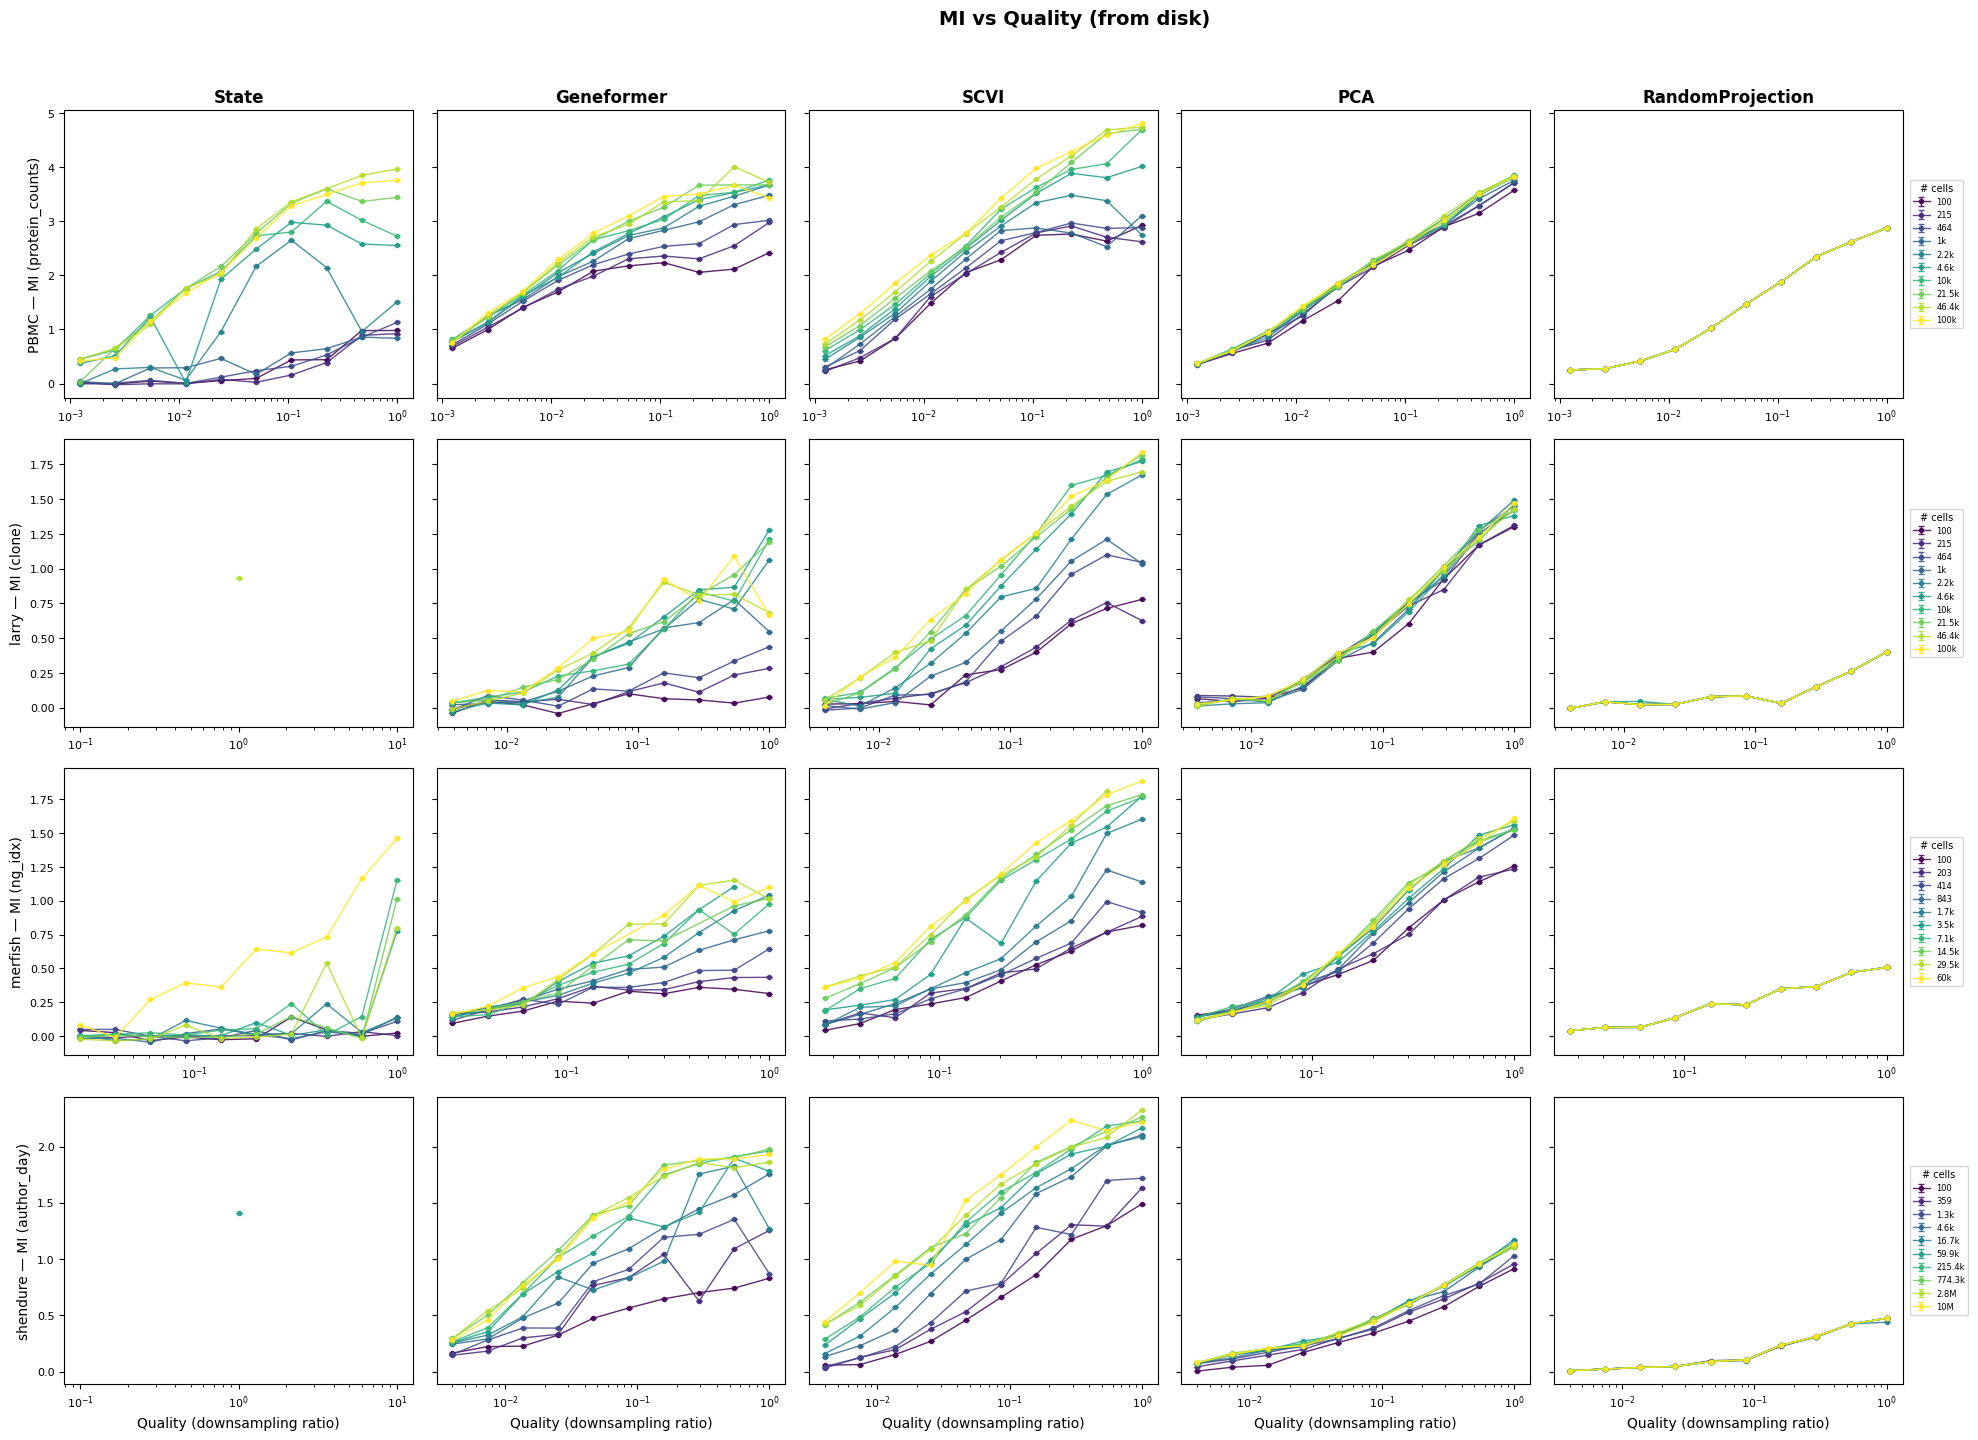

In [7]:
def _fmt_size(sz):
    """Human-readable size label: 100, 1k, 10k, 1M, 10M, etc."""
    if sz >= 1_000_000:
        return f'{sz/1_000_000:.0f}M' if sz % 1_000_000 == 0 else f'{sz/1_000_000:.1f}M'
    if sz >= 1_000:
        return f'{sz/1_000:.0f}k' if sz % 1_000 == 0 else f'{sz/1_000:.1f}k'
    return str(sz)

def plot_mi_vs_quality(df):
    """Plot MI vs quality: rows=dataset×signal, cols=algorithm, curves=size.
    Per-dataset color norm and legend to the right of each row."""
    all_ds_sig = sorted(set(zip(df['dataset'], df['signal'])))
    algorithms = [a for a in ALGO_ORDER if a in df['algorithm'].unique()]
    n_rows = len(all_ds_sig)
    n_cols = len(algorithms)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols + 1.6, 3.5 * n_rows + 0.8),
                             squeeze=False, sharex=False)

    # Share y-axis within each row
    for i in range(n_rows):
        for j in range(1, n_cols):
            axes[i, j].sharey(axes[i, 0])

    cmap = plt.cm.viridis

    # Per-dataset size norms
    ds_norms = {}
    for ds, _ in all_ds_sig:
        sizes = sorted(df[df['dataset'] == ds]['size'].unique())
        if sizes:
            ds_norms[ds] = mcolors.LogNorm(vmin=min(sizes), vmax=max(sizes))

    for i, (ds, sig) in enumerate(all_ds_sig):
        norm = ds_norms.get(ds)
        for j, algo in enumerate(algorithms):
            ax = axes[i, j]
            sub = df[(df['dataset'] == ds) & (df['algorithm'] == algo) & (df['signal'] == sig)]

            if sub.empty:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes, color='gray', fontsize=10)
                ax.set_xscale('log')
            else:
                for sz in sorted(sub['size'].unique()):
                    color = cmap(norm(sz))
                    sz_df = sub[sub['size'] == sz]
                    agg = sz_df.groupby('quality')['mi_value'].agg(['mean', 'std', 'count']).reset_index()
                    agg = agg.sort_values('quality')
                    agg['sem'] = (agg['std'] / np.sqrt(agg['count'])).fillna(0)
                    ax.errorbar(agg['quality'], agg['mean'], yerr=agg['sem'],
                                marker='o', markersize=3, linewidth=1, capsize=2,
                                color=color, alpha=0.85, label=_fmt_size(sz))
                ax.set_xscale('log')

            if i == n_rows - 1:
                ax.set_xlabel('Quality (downsampling ratio)', fontsize=10)
            if j == 0:
                ax.set_ylabel(f'{ds} — MI ({sig})', fontsize=10)
            if i == 0:
                ax.set_title(algo, fontsize=12, fontweight='bold')
            ax.tick_params(labelsize=8)
            if j > 0:
                ax.tick_params(labelleft=False)

        # Legend to the right of the last column for this row
        last_ax = axes[i, n_cols - 1]
        handles, labels = last_ax.get_legend_handles_labels()
        if handles:
            last_ax.legend(handles, labels, title='# cells', fontsize=6,
                           title_fontsize=7, loc='center left',
                           bbox_to_anchor=(1.02, 0.5), borderaxespad=0,
                           frameon=True, framealpha=0.8)

    fig.suptitle('MI vs Quality (from disk)',
                 fontsize=14, fontweight='bold')
    fig.tight_layout(rect=[0, 0.01, 0.92, 0.96])
    plt.show()
    return fig

fig_quality = plot_mi_vs_quality(df_plot)